<a href="https://colab.research.google.com/github/HurtovaAlina/ITStep-AI/blob/superwised_learning/practice_histograms_boxes_superwised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/Used%20Car%20Dataset.csv", index_col="Unnamed: 0")
df.drop(columns=['car_name'], inplace=True)
#df.drop(columns=['car_name', 'registration_year', 'ownsership', 'transmission'], inplace=True)

Дані про ціни вживаних автомобілів у Індії
* car_name - назва авто у форматі 'рік компанія основна назва'
* registration_year - місяць та рік реєстрації
* ownsership - кількість власників у форматі 'Second owner'
* transmission - тип коробки передач
* insurance_validity - тип страховки
* fuel_type - вид палива
* seats - кількість сидінь
* kms_driven - пробіг
* manufacturing_year - рік виробництва, має тип object, потрібно застосувати astype(int)
* mileage(kmpl) - скільки кілометрів проїде за літр палива
* engine(cc) - об'єм двигуна у мл
* max_power(bhp) - потужність у кінських силах
* torque(Nm) - крутний момент двигуна
* price(in lakhs) - ціна у сто тисяч рупій

[Повний аналіз даних](https://www.kaggle.com/code/abdelrasoul/used-cars-prices-prediction)

In [7]:
df.head()

,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0,63.75
1,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0,8.99
2,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0,23.75
3,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0,13.56
4,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0,24.00


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [8]:
df.shape

(1553, 13)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1553 entries, 0 to 1552
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   registration_year   1553 non-null   object 
 1   insurance_validity  1553 non-null   object 
 2   fuel_type           1553 non-null   object 
 3   seats               1553 non-null   int64  
 4   kms_driven          1553 non-null   int64  
 5   ownsership          1553 non-null   object 
 6   transmission        1553 non-null   object 
 7   manufacturing_year  1553 non-null   object 
 8   mileage(kmpl)       1550 non-null   float64
 9   engine(cc)          1550 non-null   float64
 10  max_power(bhp)      1550 non-null   float64
 11  torque(Nm)          1549 non-null   float64
 12  price(in lakhs)     1553 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 169.9+ KB


In [10]:
df.isna().sum()

,0
registration_year,0
insurance_validity,0
fuel_type,0
seats,0
kms_driven,0
ownsership,0
transmission,0
manufacturing_year,0
mileage(kmpl),3
engine(cc),3


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

In [11]:
df.describe()

,seats,kms_driven,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
count,1553.000000,1553.000000,1550.000000,1.550000e+03,1.550000e+03,1.549000e+03,1553.000000
mean,91.480361,52841.931101,236.927277,1.471857e+10,1.471857e+10,1.423989e+04,166.141494
std,2403.424060,40067.800347,585.964295,2.185629e+11,2.185629e+11,9.666241e+04,3478.855090
min,4.000000,620.000000,7.810000,5.000000e+00,5.000000e+00,5.000000e+00,1.000000
25%,5.000000,30000.000000,16.342500,1.197000e+03,1.197000e+03,4.000000e+02,4.660000
50%,5.000000,49134.000000,18.900000,1.462000e+03,1.462000e+03,1.173000e+03,7.140000
75%,5.000000,70000.000000,22.000000,1.995000e+03,1.995000e+03,8.850000e+03,17.000000
max,67000.000000,810000.000000,3996.000000,3.258640e+12,3.258640e+12,1.464800e+06,95000.000000


In [12]:
df.dtypes

,0
registration_year,object
insurance_validity,object
fuel_type,object
seats,int64
kms_driven,int64
ownsership,object
transmission,object
manufacturing_year,object
mileage(kmpl),float64
engine(cc),float64


Text(0.5, 0, 'amount')

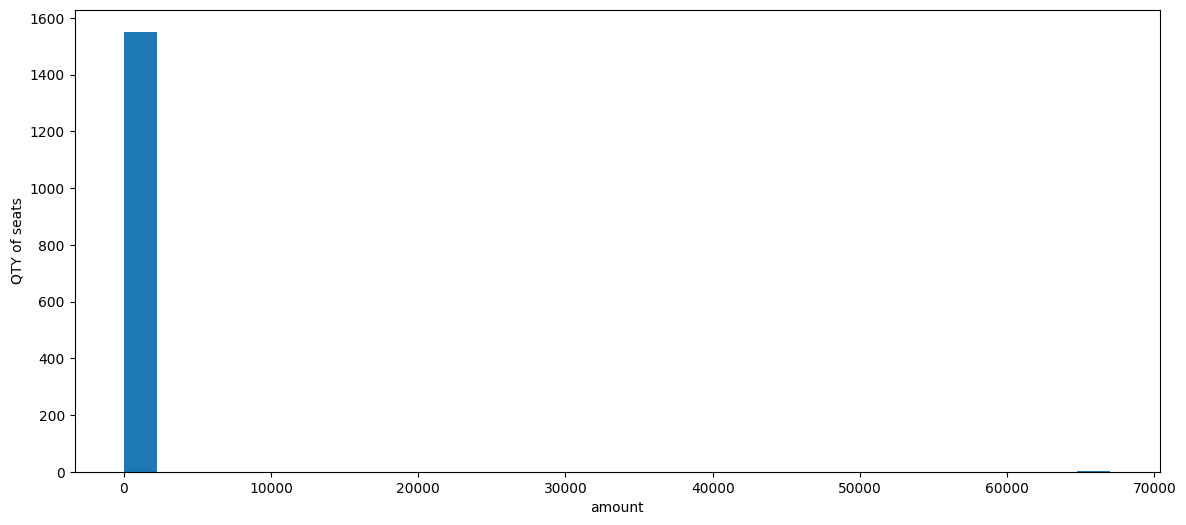

In [13]:
ax = df['seats'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('QTY of seats')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

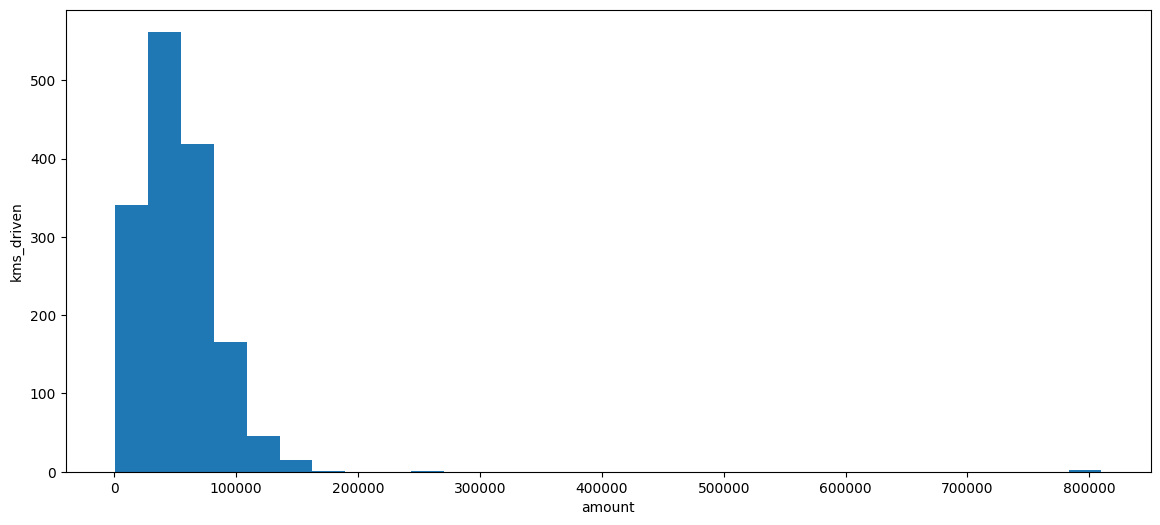

In [14]:
ax = df['kms_driven'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('kms_driven')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

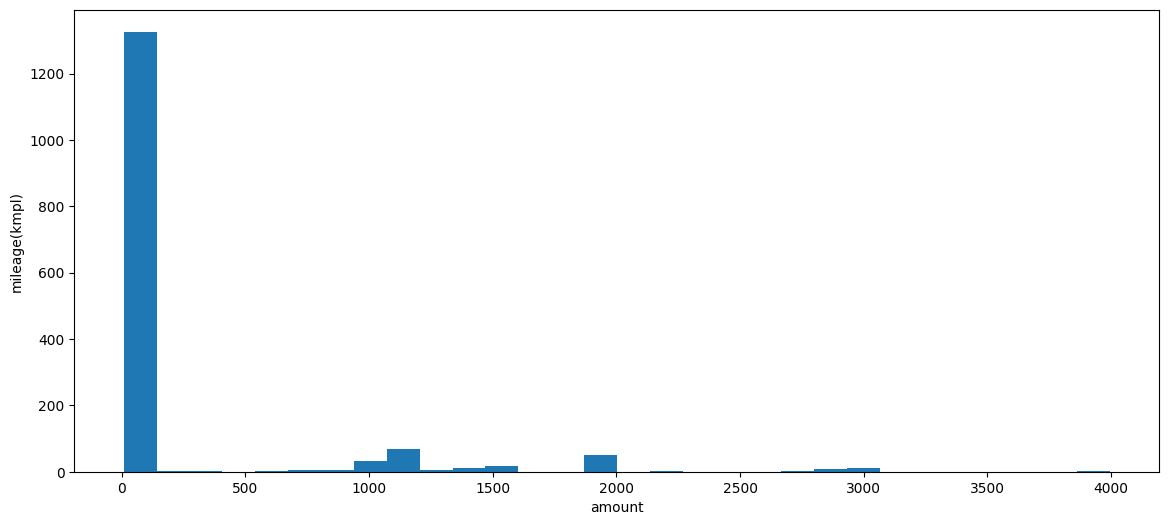

In [15]:
ax = df['mileage(kmpl)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('mileage(kmpl)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

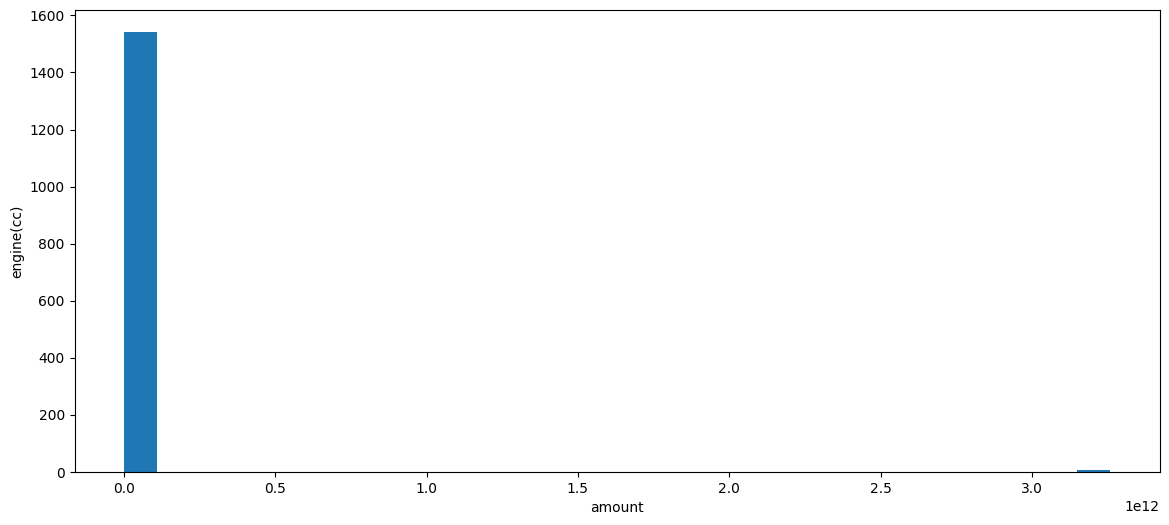

In [16]:
ax = df['engine(cc)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('engine(cc)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

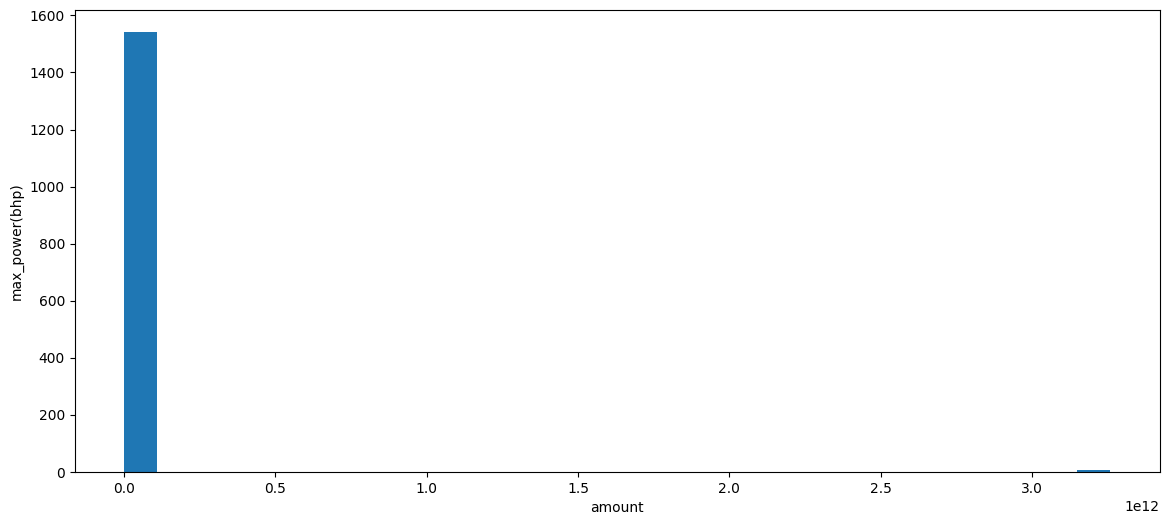

In [17]:
ax = df['max_power(bhp)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('max_power(bhp)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

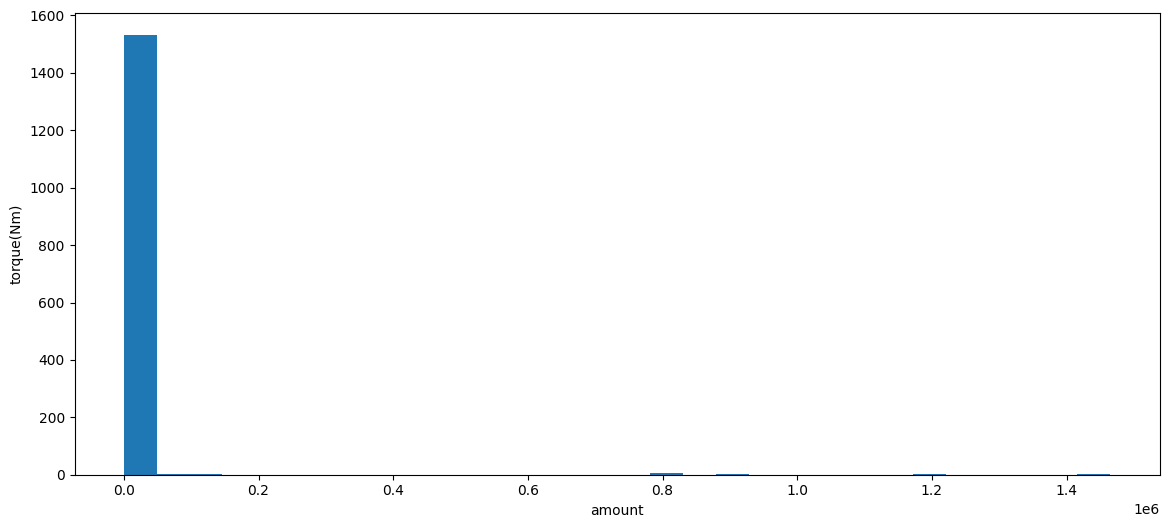

In [18]:
ax = df['torque(Nm)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('torque(Nm)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

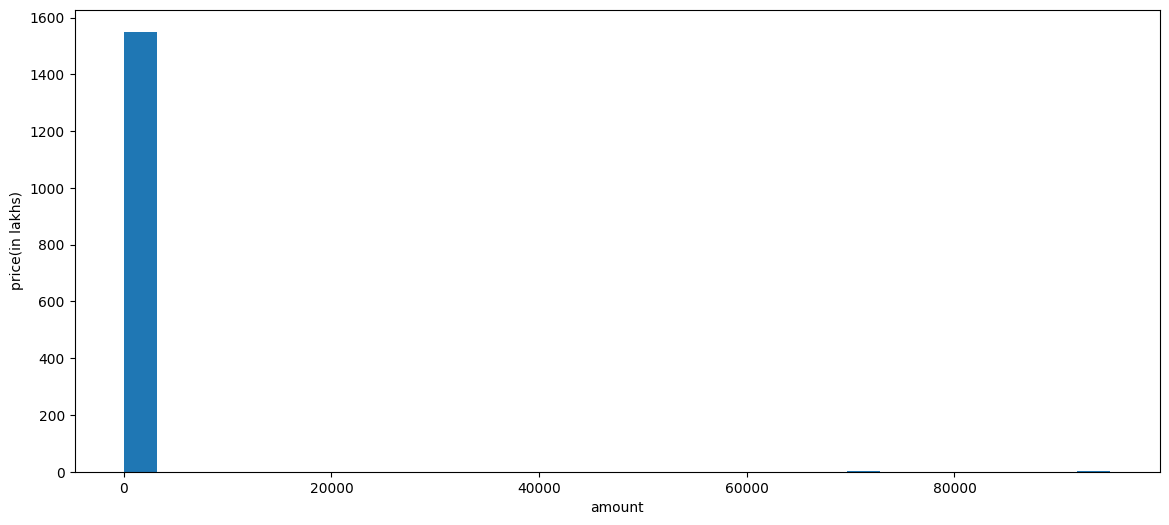

In [19]:
ax = df['price(in lakhs)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('price(in lakhs)')
ax.set_xlabel('amount')

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

In [20]:
df.dtypes

,0
registration_year,object
insurance_validity,object
fuel_type,object
seats,int64
kms_driven,int64
ownsership,object
transmission,object
manufacturing_year,object
mileage(kmpl),float64
engine(cc),float64


In [21]:
mask= df['seats']<1000
mask.sum()

np.int64(1551)

In [22]:
df = df[mask]

<Axes: >

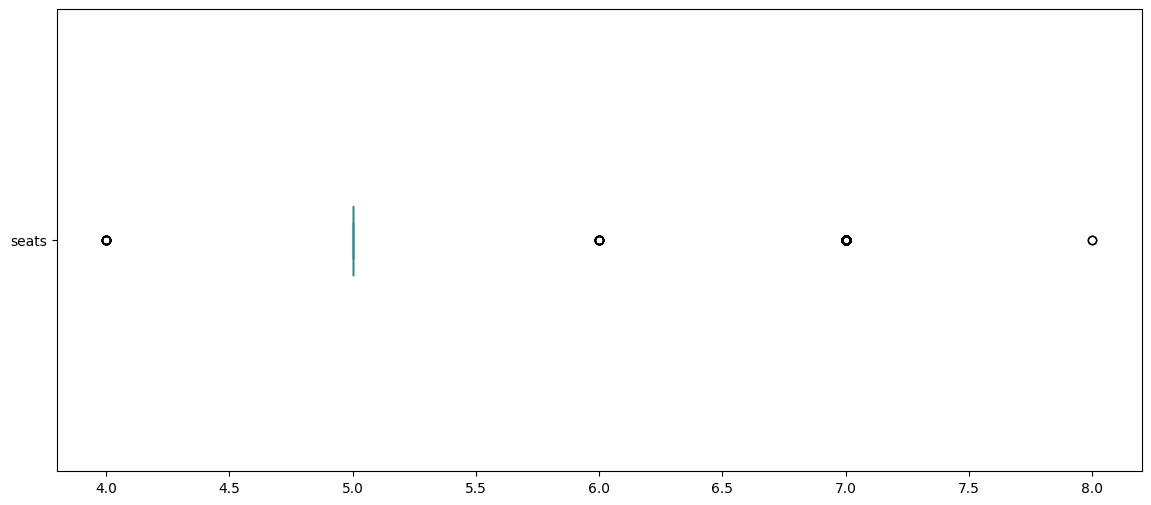

In [23]:
df['seats'].plot(kind='box', vert=False, figsize=(14,6))

In [24]:
mask= df['kms_driven']<175000
mask.sum()

np.int64(1547)

In [25]:
df = df[mask]

<Axes: >

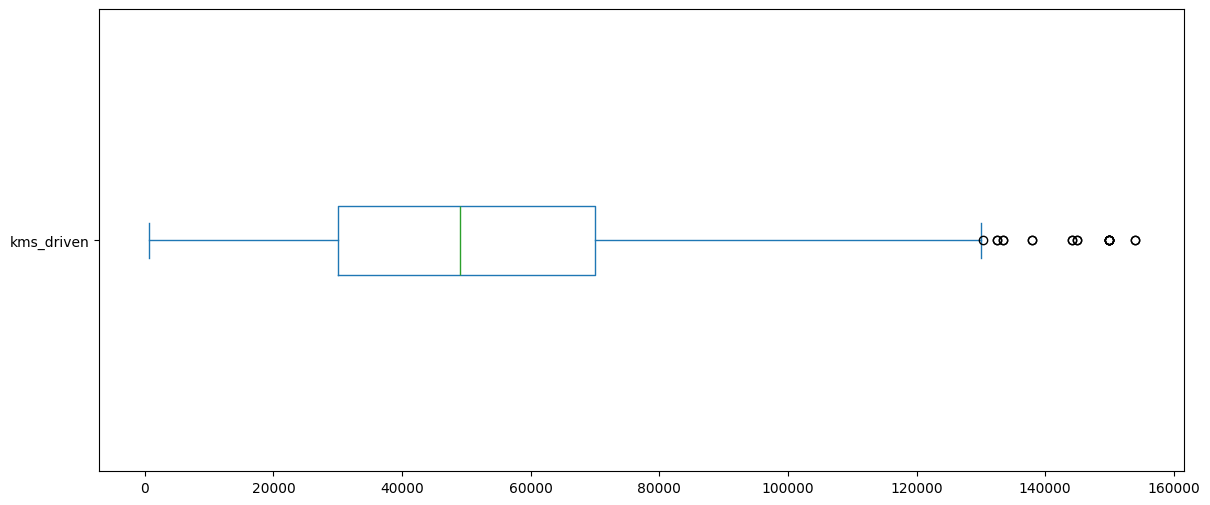

In [26]:
df['kms_driven'].plot(kind='box', vert=False, figsize=(14,6))

In [27]:
mask= df['mileage(kmpl)']<100
mask.sum()

np.int64(1322)

In [28]:
df = df[mask]

<Axes: >

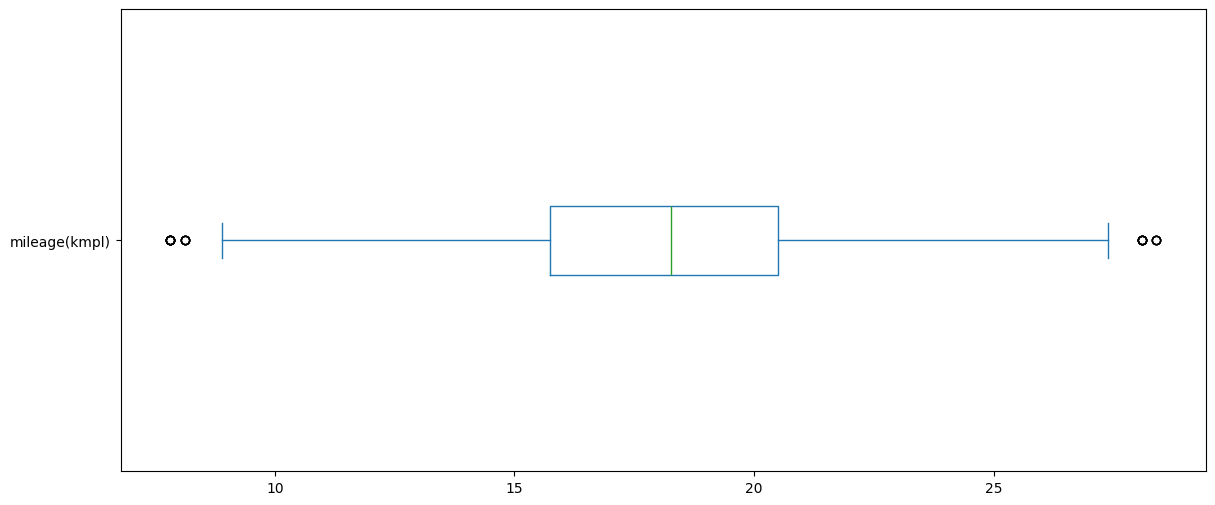

In [29]:
df['mileage(kmpl)'].plot(kind='box', vert=False, figsize=(14,6))

In [30]:
mask= df['engine(cc)']<10000
mask.sum()

np.int64(1322)

In [31]:
df = df[mask]

<Axes: >

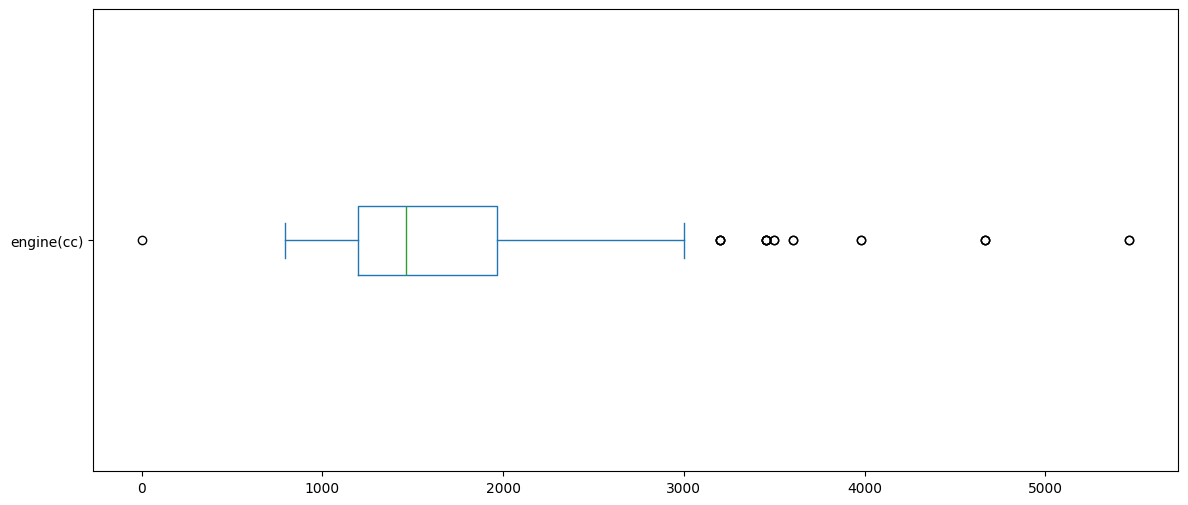

In [32]:
df['engine(cc)'].plot(kind='box', vert=False, figsize=(14,6))

In [33]:
mask= df['max_power(bhp)']<4000
mask.sum()

np.int64(1317)

In [34]:
df = df[mask]

<Axes: >

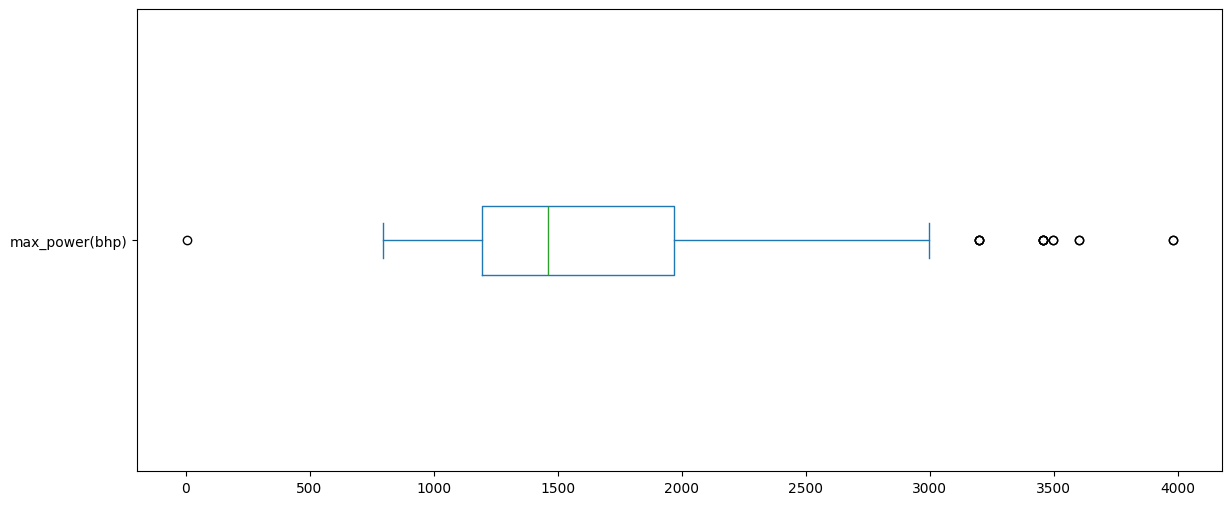

In [35]:
df['max_power(bhp)'].plot(kind='box', vert=False, figsize=(14,6))

In [36]:
mask= df['torque(Nm)']<55000
mask.sum()

np.int64(1302)

In [37]:
df = df[mask]

<Axes: >

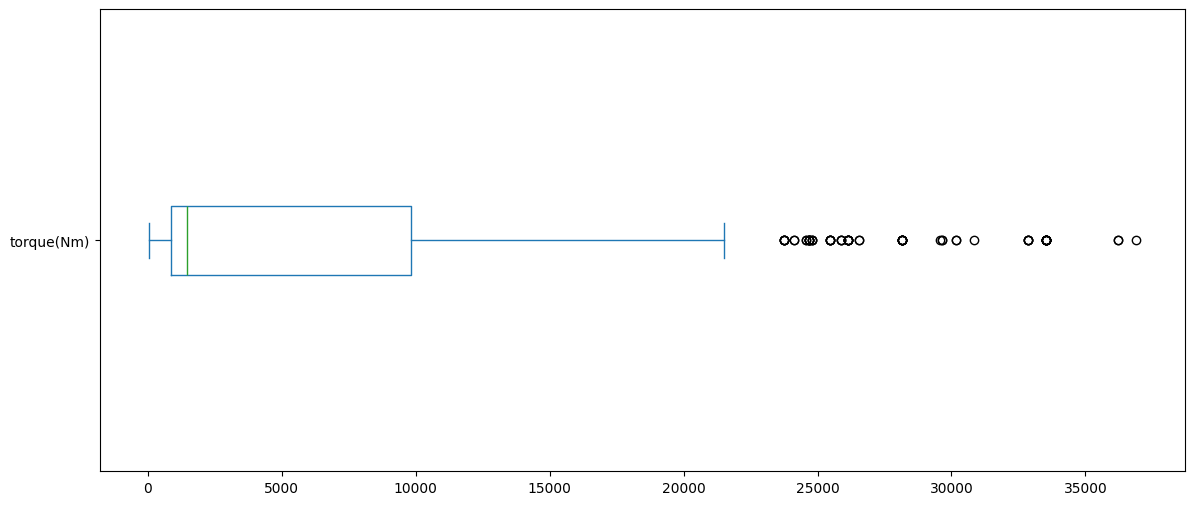

In [38]:
df['torque(Nm)'].plot(kind='box', vert=False, figsize=(14,6))

In [39]:
mask= df['price(in lakhs)']<60
mask.sum()

np.int64(1246)

In [40]:
df = df[mask]

<Axes: >

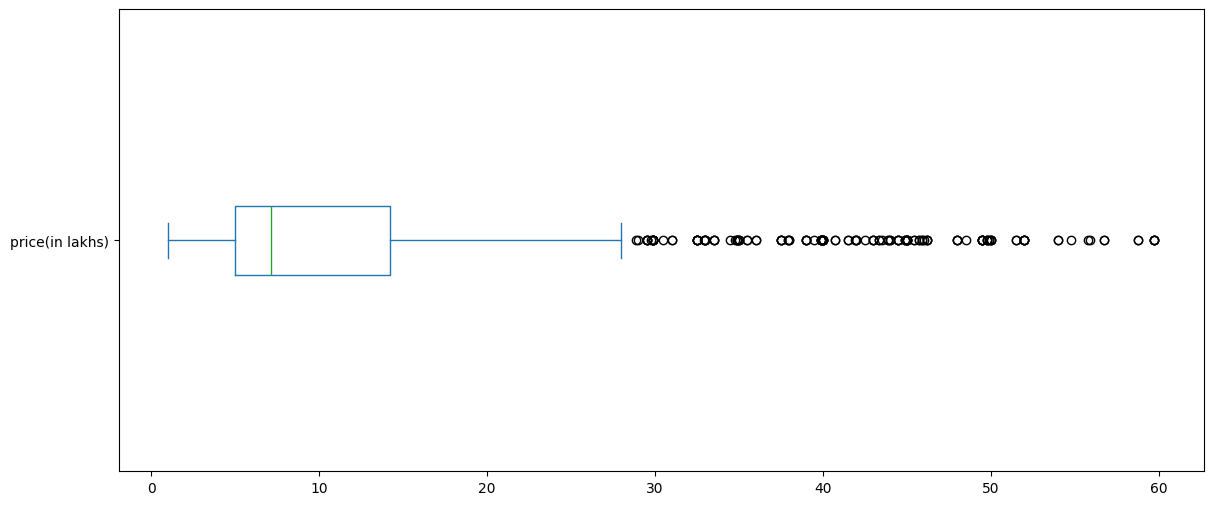

In [41]:
df['price(in lakhs)'].plot(kind='box', vert=False, figsize=(14,6))

# Завдання 4
Створіть Pipeline для обробки даних

In [42]:
df.shape

(1246, 13)

In [43]:
# кількість пропусків
df.isnull().sum()

,0
registration_year,0
insurance_validity,0
fuel_type,0
seats,0
kms_driven,0
ownsership,0
transmission,0
manufacturing_year,0
mileage(kmpl),0
engine(cc),0


In [44]:
#поділ даних на тренувальні і валідаційні
y = df['price(in lakhs)']
X = df.drop(columns='price(in lakhs)')

X.head()

,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm)
1,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0
2,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0
3,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0
4,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0
5,Jul-17,Third Party insurance,Petrol,5,42000,First Owner,Manual,2017,18.70,1199.0,1199.0,887.0


In [45]:
X

,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm)
1,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0
2,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0
3,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0
4,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0
5,Jul-17,Third Party insurance,Petrol,5,42000,First Owner,Manual,2017,18.70,1199.0,1199.0,887.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1546,May-18,Comprehensive,Petrol,5,19446,First Owner,Automatic,2018,18.20,1199.0,1199.0,887.0
1547,May-22,Third Party insurance,CNG,7,26500,First Owner,Manual,2022,26.11,1462.0,1462.0,8663.0
1550,Jun-17,Comprehensive,Petrol,5,49000,First Owner,Manual,2017,17.50,1199.0,1199.0,887.0
1551,May-18,Comprehensive,Petrol,5,40000,Second Owner,Manual,2018,18.78,999.0,999.0,75.0


In [46]:
y

,price(in lakhs)
1,8.99
2,23.75
3,13.56
4,24.00
5,5.45
...,...
1546,6.50
1547,11.50
1550,5.85
1551,4.75


In [47]:
# поділ на тренувальні і валідаційні
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8,
                                                    random_state=42
                                                    )

X_train.shape, X_test.shape

((996, 12), (250, 12))

In [48]:
# побудова пайплайну
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [49]:
# поділ колонок на числові і тестові значення
num_columns = X_train.select_dtypes(include='number').columns
cat_columns = X_train.select_dtypes(include='object').columns



In [50]:
# колонки з числовими значеннями
num_columns

Index(['seats', 'kms_driven', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)',
       'torque(Nm)'],
      dtype='object')

In [51]:
# колонки з текстовими значеннями
cat_columns

Index(['registration_year', 'insurance_validity', 'fuel_type', 'ownsership',
       'transmission', 'manufacturing_year'],
      dtype='object')

In [52]:
# пайплайн для числових значень - якщо є пропуски числових значень, заповнює медіанним значенням
num_transformer = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

num_transformer

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('scale', StandardScaler())])

In [76]:
# пайплайн для тесктових значень, якщо є пропуски, заповнить значенням Unknown
# handle_unknown='ignore' Якщо не зустрічав таке значення під час навчання, не буде падати з помилкою — просто закодує цю категорію як усі нулі.
cat_transformer = Pipeline(
    [
        ('impute', SimpleImputer(strategy='constant',   # strategy='most_frequent'
                                 fill_value='UNKNOWN')),
         ('onehot', OneHotEncoder(sparse_output=False,
        handle_unknown='ignore'))
    ]
)

cat_transformer

Pipeline(steps=[('impute',
                 SimpleImputer(fill_value='UNKNOWN', strategy='constant')),
                ('onehot',
                 OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

In [77]:
# препроцессор будує таблицю заповнену числовими значеннями (в т.ч тесктові преобразовані в числові)
preprocessor = ColumnTransformer(
    [
        ('num', num_transformer, num_columns),
        ('cat', cat_transformer, cat_columns)
    ]
)

preprocessor.set_output(transform='pandas')
preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 Index(['seats', 'kms_driven', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)',
       'torque(Nm)'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(fill_value='UNKNOWN',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['registration_year', 'insurance_validity', 'fuel_type', 'ownsership',
       'transmission', 'manufacturing_year'],
      dtype='object'))])

In [78]:
X_train

,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm)
495,Jul-16,Third Party insurance,Diesel,5,70000,Second Owner,Automatic,2016,20.68,1995.0,1995.0,188.0
324,2012,Third Party insurance,Petrol,5,110000,Second Owner,Automatic,2012,12.05,1995.0,1995.0,154.0
1325,Nov-15,Comprehensive,Diesel,5,84000,First Owner,Manual,2015,25.10,1498.0,1498.0,986.0
1289,Dec-20,Comprehensive,Petrol,5,32997,First Owner,Manual,2020,22.05,796.0,796.0,4733.0
389,May-12,Comprehensive,Petrol,5,48936,Second Owner,Manual,2011,19.00,998.0,998.0,661.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1310,Nov-18,Third Party insurance,Diesel,5,52000,First Owner,Manual,2018,19.67,1582.0,1582.0,1262.0
1375,Feb-21,Comprehensive,Petrol,4,7421,First Owner,Automatic,2021,15.20,1997.0,1997.0,150.0
1411,2018,Third Party insurance,Diesel,7,40000,First Owner,Automatic,2018,14.75,2967.0,2967.0,245.0
1080,Jul-12,Comprehensive,Petrol,5,47925,First Owner,Manual,2012,16.80,1497.0,1497.0,1163.0


In [79]:
# трансформація таблиці
preprocessor.fit_transform(X_train)

,num__seats,num__kms_driven,num__mileage(kmpl),num__engine(cc),num__max_power(bhp),num__torque(Nm),cat__registration_year_2007,cat__registration_year_2009,cat__registration_year_2010,cat__registration_year_2012,...,cat__manufacturing_year_2014,cat__manufacturing_year_2015,cat__manufacturing_year_2016,cat__manufacturing_year_2017,cat__manufacturing_year_2018,cat__manufacturing_year_2019,cat__manufacturing_year_2020,cat__manufacturing_year_2021,cat__manufacturing_year_2022,cat__manufacturing_year_2023
495,-0.320865,0.548685,0.659806,0.831038,0.831038,-0.830391,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
324,-0.320865,1.928444,-1.729228,0.831038,0.831038,-0.835493,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1325,-0.320865,1.031601,1.883390,-0.122992,-0.122992,-0.710642,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1289,-0.320865,-0.727695,1.039062,-1.470535,-1.470535,-0.148362,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
389,-0.320865,-0.177896,0.194734,-1.082780,-1.082780,-0.759412,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1310,-0.320865,-0.072206,0.380209,0.038253,0.038253,-0.669225,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1375,-1.959743,-1.609913,-0.857216,0.834877,0.834877,-0.836093,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1411,2.956892,-0.486134,-0.981790,2.696867,2.696867,-0.821837,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1080,-0.320865,-0.212769,-0.414290,-0.124911,-0.124911,-0.684081,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [80]:
# вивід тренувальної таблиці
X_train

,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm)
495,Jul-16,Third Party insurance,Diesel,5,70000,Second Owner,Automatic,2016,20.68,1995.0,1995.0,188.0
324,2012,Third Party insurance,Petrol,5,110000,Second Owner,Automatic,2012,12.05,1995.0,1995.0,154.0
1325,Nov-15,Comprehensive,Diesel,5,84000,First Owner,Manual,2015,25.10,1498.0,1498.0,986.0
1289,Dec-20,Comprehensive,Petrol,5,32997,First Owner,Manual,2020,22.05,796.0,796.0,4733.0
389,May-12,Comprehensive,Petrol,5,48936,Second Owner,Manual,2011,19.00,998.0,998.0,661.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1310,Nov-18,Third Party insurance,Diesel,5,52000,First Owner,Manual,2018,19.67,1582.0,1582.0,1262.0
1375,Feb-21,Comprehensive,Petrol,4,7421,First Owner,Automatic,2021,15.20,1997.0,1997.0,150.0
1411,2018,Third Party insurance,Diesel,7,40000,First Owner,Automatic,2018,14.75,2967.0,2967.0,245.0
1080,Jul-12,Comprehensive,Petrol,5,47925,First Owner,Manual,2012,16.80,1497.0,1497.0,1163.0


In [81]:
# остаточна модель - побудова дерева рішень

from sklearn.tree import DecisionTreeRegressor


full_model = Pipeline([
    ('prep', preprocessor),
    ('tree', DecisionTreeRegressor(max_depth=5,
                                   min_samples_leaf=5,
                                   random_state=42))
])

In [82]:
full_model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['seats', 'kms_driven', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)',
       'torque(Nm)'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='UNKNOWN',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['registration_year', 'insurance_validity', 'fuel_type', 'ownsership',
       'transmission', 'manufacturing_year'],
      dtype='object'))])),
                ('tree',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=5,
                                       random_state=42))])

In [83]:
# натренувати модель
full_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  Index(['seats', 'kms_driven', 'mileage(kmpl)', 'engine(cc)', 'max_power(bhp)',
       'torque(Nm)'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(fill_value='UNKNOWN',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['registration_year', 'insurance_validity', 'fuel_type', 'ownsership',
       'transmission', 'manufacturing_year'],
      dtype='object'))])),
                ('tree',
                 DecisionTreeRegressor(max_depth=5, min_samples_leaf=5,
                                       random_state=42))])

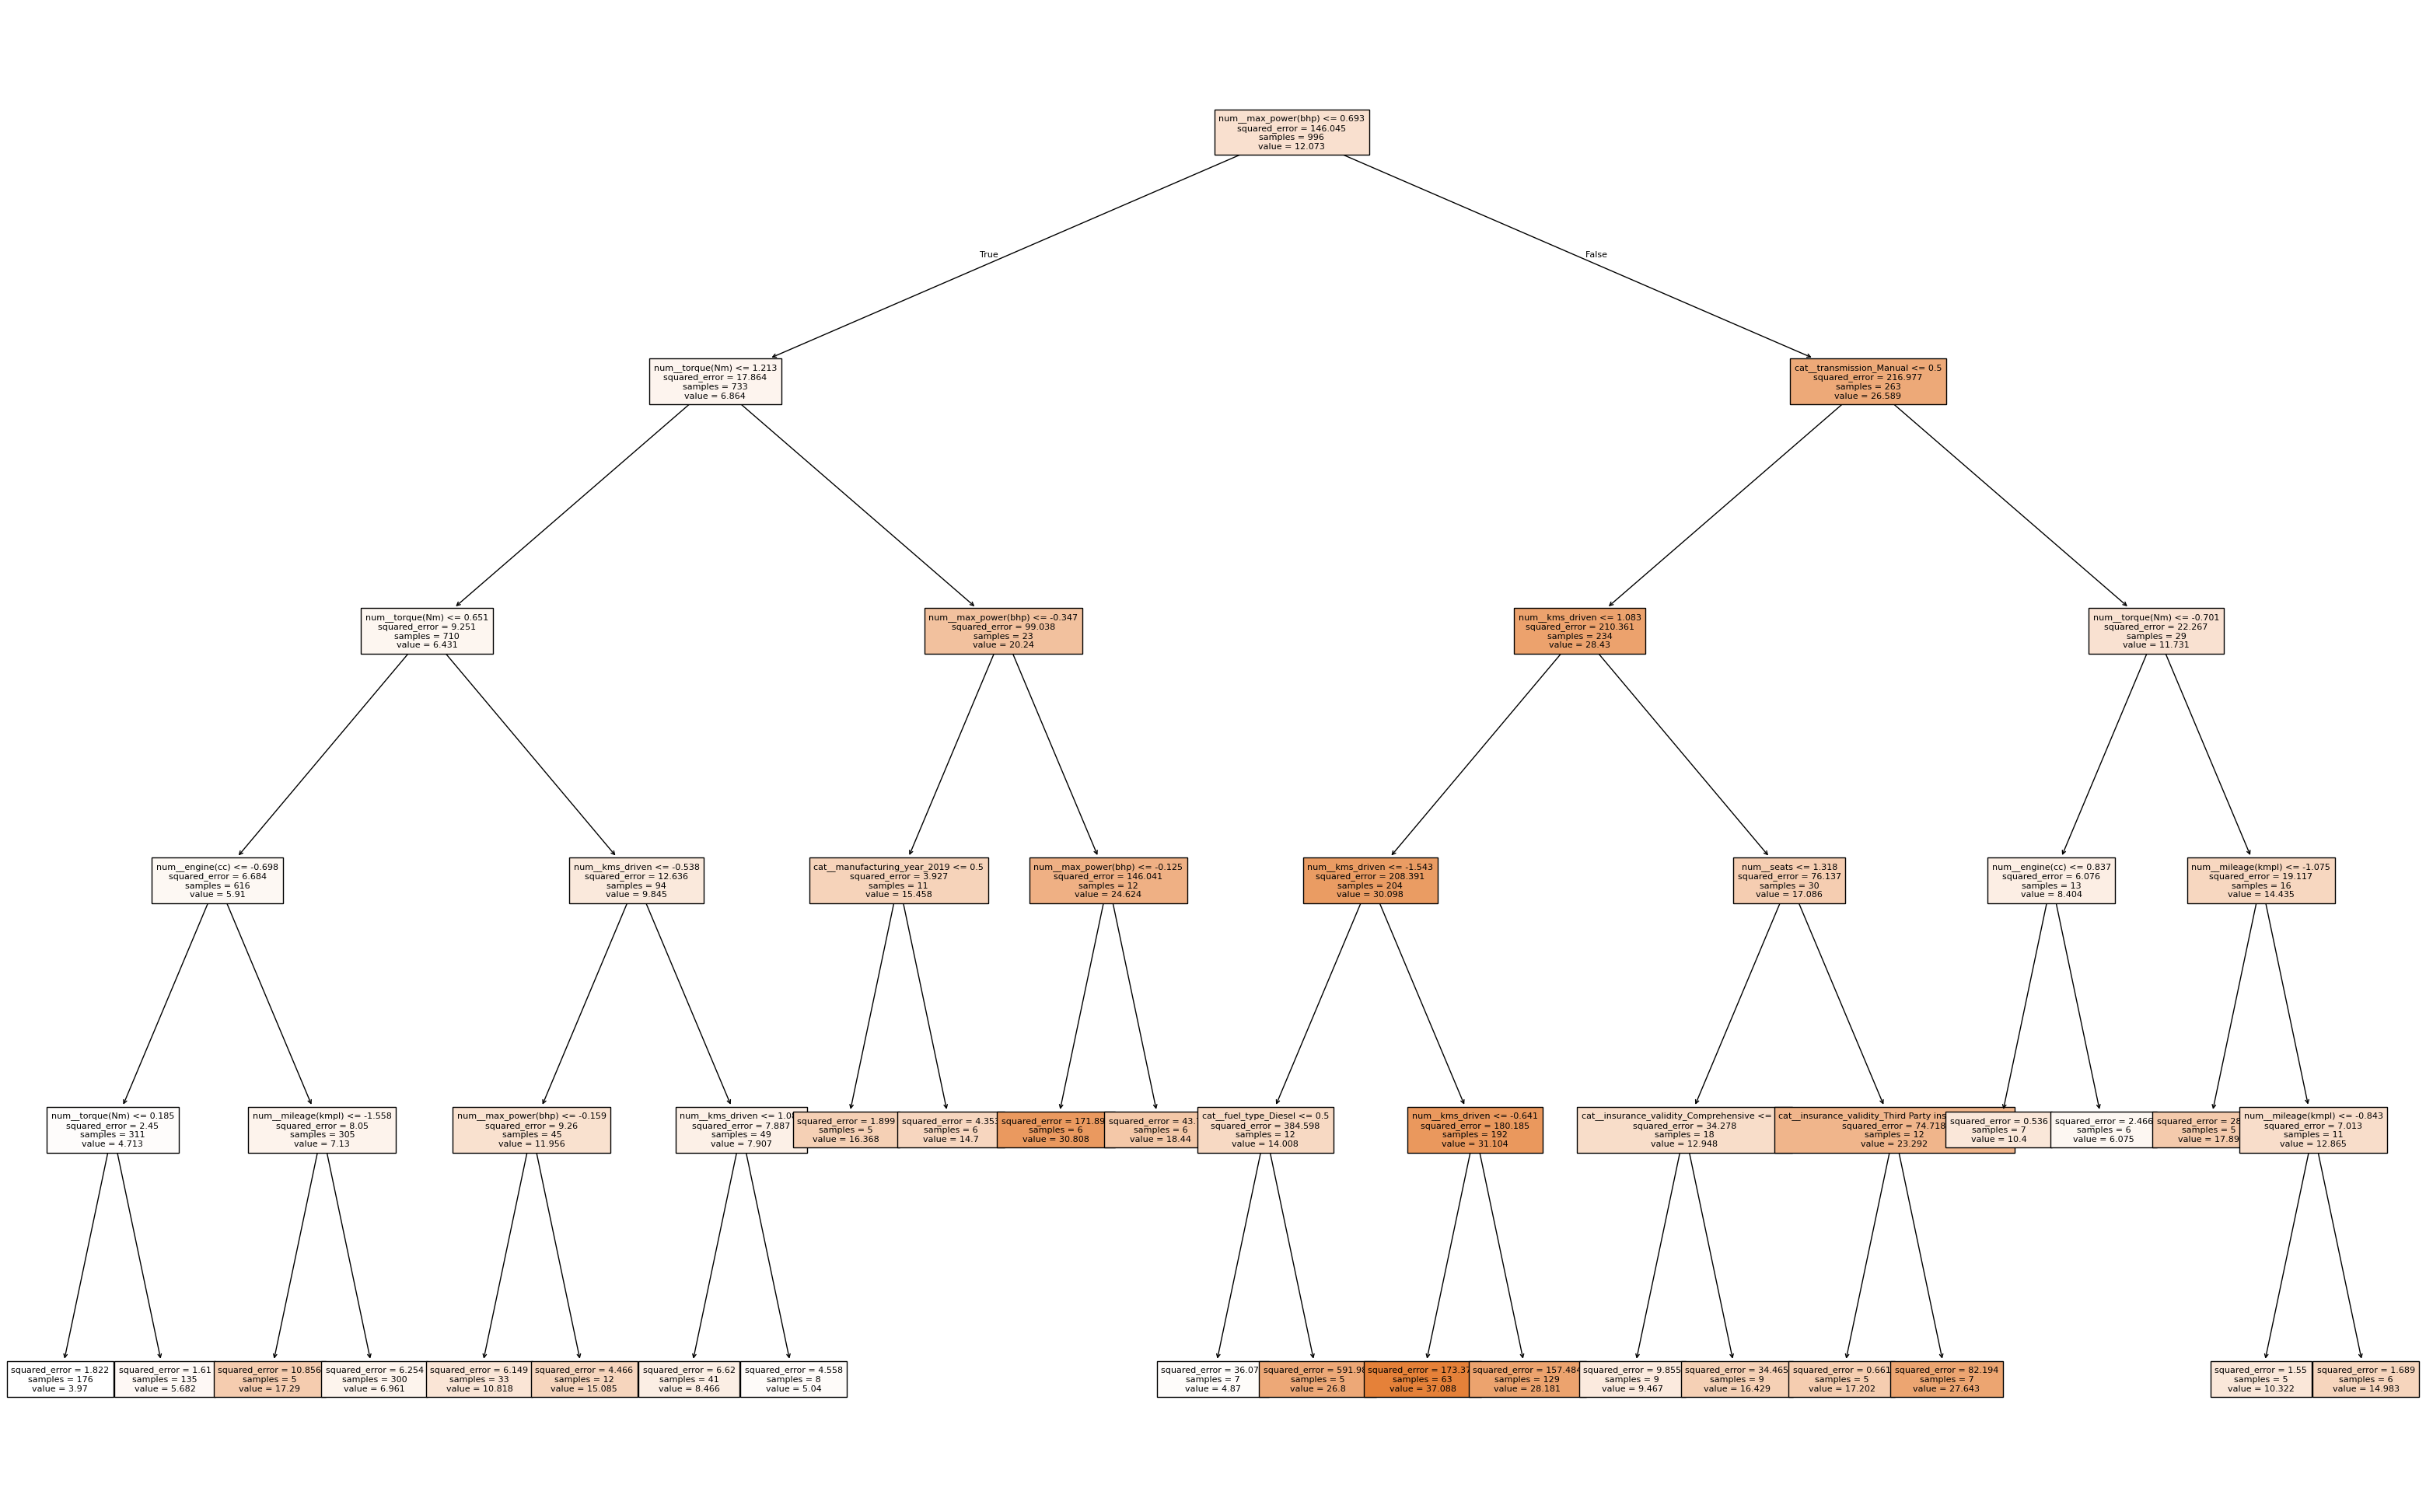

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [84]:

# перегляд дерева та збереження його у файл

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from google.colab import files

# дістаємо саме дерево з Pipeline
tree = full_model.named_steps['tree']

# отримуємо назви ознак після preprocessing
feature_names = full_model.named_steps['prep'].get_feature_names_out()

# створюємо малюнок
plt.figure(figsize=(40, 25))

plot_tree(
    tree,
    filled=True,
    feature_names=feature_names,
    fontsize=8
)

# зберігаємо дерево у PDF
plt.savefig(
    'decision_tree.pdf',
    bbox_inches='tight'
)

plt.show()

# завантажуємо PDF на комп'ютер
files.download('decision_tree.pdf')

In [85]:
from sklearn import metrics

In [86]:
y_pred = full_model.predict(X_test)



In [87]:
y_pred

array([ 6.96103333, 37.08777778,  8.46634146,  6.96103333, 28.18147287,
        3.96988636,  6.96103333, 16.368     ,  8.46634146, 28.18147287,
        3.96988636,  3.96988636,  6.96103333,  6.96103333, 28.18147287,
        5.682     ,  6.96103333, 17.89      , 17.89      ,  3.96988636,
        5.682     ,  6.96103333,  5.682     , 28.18147287,  3.96988636,
        3.96988636, 28.18147287,  6.96103333,  3.96988636, 17.202     ,
        3.96988636, 28.18147287, 37.08777778, 37.08777778, 28.18147287,
       28.18147287, 10.81848485,  5.682     , 37.08777778,  5.04      ,
       28.18147287, 28.18147287,  6.96103333,  6.96103333,  3.96988636,
       30.80833333, 18.44      ,  6.075     ,  3.96988636,  3.96988636,
        3.96988636,  8.46634146,  6.96103333, 28.18147287,  3.96988636,
        3.96988636, 10.322     , 28.18147287, 28.18147287, 28.18147287,
        6.96103333,  6.96103333,  3.96988636, 28.18147287, 28.18147287,
       28.18147287, 28.18147287, 14.98333333, 28.18147287, 37.08

In [88]:
# копія таблиці
result = X_test.copy()

In [90]:
# додаємо реальну ціну
result['actual_price'] = y_test.values

# додаємо передбачену ціну
result['predicted_price'] = y_pred

# показуємо таблицю
result

# X_test → характеристики автомобіля
# actual_price → справжня ціна з y_test
# predicted_price → ціна, яку передбачила модель


,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),actual_price,predicted_price
922,Sep-15,Comprehensive,Petrol,5,65000,First Owner,Manual,2015,16.80,1497.0,1497.0,1163.0,6.25,6.961033
566,Oct-19,Comprehensive,Diesel,5,35000,First Owner,Automatic,2019,20.37,1995.0,1995.0,18774.0,45.00,37.087778
1398,May-16,Comprehensive,Petrol,5,66000,First Owner,Manual,2016,16.80,1395.0,1395.0,13802.0,5.95,8.466341
416,Oct-17,Comprehensive,Diesel,5,56458,Second Owner,Manual,2017,25.50,1498.0,1498.0,986.0,5.71,6.961033
409,Mar-16,Comprehensive,Diesel,7,72222,Second Owner,Automatic,2015,14.75,2967.0,2967.0,245.0,34.90,28.181473
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,Jun-17,Comprehensive,Diesel,5,35000,First Owner,Manual,2017,19.67,1582.0,1582.0,1262.0,7.50,6.961033
1333,Jun-15,Comprehensive,Petrol,5,73616,First Owner,Manual,2015,22.00,1197.0,1197.0,8180.0,3.75,5.682000
1480,Jul-18,Comprehensive,Petrol,5,13513,First Owner,Automatic,2018,18.30,1199.0,1199.0,8876.0,7.65,6.961033
544,Jun-18,Comprehensive,Petrol,5,92539,First Owner,Manual,2018,18.60,1197.0,1197.0,8183.0,5.28,5.682000


In [91]:
# помилка прогнозу
result['difference'] = (
    result['actual_price'] - result['predicted_price']
)

result

,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),actual_price,predicted_price,difference
922,Sep-15,Comprehensive,Petrol,5,65000,First Owner,Manual,2015,16.80,1497.0,1497.0,1163.0,6.25,6.961033,-0.711033
566,Oct-19,Comprehensive,Diesel,5,35000,First Owner,Automatic,2019,20.37,1995.0,1995.0,18774.0,45.00,37.087778,7.912222
1398,May-16,Comprehensive,Petrol,5,66000,First Owner,Manual,2016,16.80,1395.0,1395.0,13802.0,5.95,8.466341,-2.516341
416,Oct-17,Comprehensive,Diesel,5,56458,Second Owner,Manual,2017,25.50,1498.0,1498.0,986.0,5.71,6.961033,-1.251033
409,Mar-16,Comprehensive,Diesel,7,72222,Second Owner,Automatic,2015,14.75,2967.0,2967.0,245.0,34.90,28.181473,6.718527
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,Jun-17,Comprehensive,Diesel,5,35000,First Owner,Manual,2017,19.67,1582.0,1582.0,1262.0,7.50,6.961033,0.538967
1333,Jun-15,Comprehensive,Petrol,5,73616,First Owner,Manual,2015,22.00,1197.0,1197.0,8180.0,3.75,5.682000,-1.932000
1480,Jul-18,Comprehensive,Petrol,5,13513,First Owner,Automatic,2018,18.30,1199.0,1199.0,8876.0,7.65,6.961033,0.688967
544,Jun-18,Comprehensive,Petrol,5,92539,First Owner,Manual,2018,18.60,1197.0,1197.0,8183.0,5.28,5.682000,-0.402000
